# Import libraries

In [ ]:
import os
import warnings

import contextily as ctx
import geopandas as gpd
import joblib
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
import seaborn as sns

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse, Patch
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from scipy.stats import chi2
from skbio import DistanceMatrix
from skbio.stats.composition import clr
from skbio.stats.ordination import pcoa
from sklearn.covariance import GraphicalLassoCV
from pyproj import Transformer
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

import mlflow

from ml.config import config
from ml.data_loading import DatabaseRSA, db_reader
from ml.features import CLRFilter, KBestFeatureSelection, MicrobiomeFeatureEngineer, ZeroColumnFilter
from ml.models import TrainTestSplit, load_and_prep_data
from ml.pipeline import build_modelling_pipeline

warnings.filterwarnings("ignore", message="invalid value encountered in subtract")

/home/chandru/binp51/.venv-all/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Plotting Style

In [2]:
# =============================================================================
# Publication plotting style
# =============================================================================

plt.style.use('default')

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize': 16,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.dpi': 300,
    'savefig.dpi': 600
})




In [8]:
samples = db_reader.DatabaseCreate(db="../databases/malmo.db")
rsa = DatabaseRSA(db="../databases/malmo.db", db_table="malmo_order")
df_order = rsa.merge_data(samples.get_samples(), rsa.sql_to_clean())
df_order = df_order.drop_duplicates(subset="sample_id")
df_order.head()

samples = db_reader.DatabaseCreate(db="../databases/malmo.db")
rsa = DatabaseRSA(db="../databases/malmo.db", db_table="malmo_phylum")
df_phylum = rsa.merge_data(samples.get_samples(), rsa.sql_to_clean())
df_phylum = df_phylum.drop_duplicates(subset="sample_id")
df_phylum.head()

,sample_id,latitude,longitude,zone,Abditibacteriota,Acanthocephala,Acidobacteriota,Actinomycetota,Annelida,Apicomplexa,...,Thermosulfidibacterota,Thermotogota,Tubulinea,Uroviricota,Verrucomicrobiota,Vulcanimicrobiota,Xenacoelomorpha,Zoopagomycota,candidate division WOR-3,candidate division WWE3
0,zr23059_1,55.582409,12.950183,Zone C - Limhamn,0.0,0.0,0.01571,0.45785,0.0,0.0,...,0.0,0.00588,0.0,0.00241,0.00253,0.0,0.0,0.0,0.0,0.0
1,zr23059_2,55.579586,13.018840,Zone H - Fosie,0.0,0.0,0.01297,0.42306,0.0,0.0,...,0.0,0.00524,0.0,0.00198,0.00241,0.0,0.0,0.0,0.0,0.0
2,zr23059_3,55.559470,13.021110,Zone H - Fosie,0.0,0.0,0.01070,0.29817,0.0,0.0,...,0.0,0.00581,0.0,0.00169,0.00352,0.0,0.0,0.0,0.0,0.0
3,zr23059_4,55.572364,12.917626,Zone C - Limhamn,0.0,0.0,0.01844,0.42235,0.0,0.0,...,0.0,0.00000,0.0,0.00170,0.00446,0.0,0.0,0.0,0.0,0.0
4,zr23059_5,55.559686,13.012436,Zone H - Fosie,0.0,0.0,0.01535,0.52822,0.0,0.0,...,0.0,0.00000,0.0,0.00157,0.00399,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Load your data (adjust the filename)
df = df_phylum  # or however you load your df_phylum

# 1. Project coordinates to metres (SWEREF99 TM)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3006", always_xy=True)
x_m, y_m = transformer.transform(df["longitude"].to_numpy(), df["latitude"].to_numpy())
df['x_m'] = x_m
df['y_m'] = y_m

coords = df[['x_m', 'y_m']].to_numpy()

# 2. For each sample, find distance to its nearest neighbour
nn = NearestNeighbors(n_neighbors=2, metric='euclidean')
nn.fit(coords)
distances, _ = nn.kneighbors(coords)
# The first column is distance to itself (0), second is nearest neighbour distance
nearest_distances = distances[:, 1]

# 3. Summary statistics
print("=" * 60)
print("Spatial Proximity Summary")
print("=" * 60)
print(f"Total samples: {len(df)}")
print(f"\nNearest neighbour distances (metres):")
print(f"  Mean:   {nearest_distances.mean():.2f} m")
print(f"  Std:    {nearest_distances.std():.2f} m")
print(f"  Min:    {nearest_distances.min():.2f} m")
print(f"  10th percentile: {np.percentile(nearest_distances, 10):.2f} m")
print(f"  25th percentile: {np.percentile(nearest_distances, 25):.2f} m")
print(f"  Median: {np.median(nearest_distances):.2f} m")
print(f"  75th percentile: {np.percentile(nearest_distances, 75):.2f} m")
print(f"  90th percentile: {np.percentile(nearest_distances, 90):.2f} m")
print(f"  Max:    {nearest_distances.max():.2f} m")

# 4. Count samples that are very close (within typical GPS precision)
for threshold in [5, 10, 15, 20, 25, 30]:
    count = np.sum(nearest_distances <= threshold)
    print(f"  Samples with NN <= {threshold}m: {count} ({count/len(df)*100:.1f}%)")

# 5. Recommendation
print("\n" + "=" * 60)
print("RECOMMENDATION")
print("=" * 60)

# Suggest a threshold based on the 25th percentile (or 10th)
suggested_threshold = np.percentile(nearest_distances, 10)
print(f"Based on the 10th percentile (the smallest 10% of nearest-neighbour distances),\n"
      f"a reasonable threshold would be: {suggested_threshold:.2f} metres.")

Spatial Proximity Summary
Total samples: 262

Nearest neighbour distances (metres):
  Mean:   39.54 m
  Std:    91.79 m
  Min:    0.00 m
  10th percentile: 1.23 m
  25th percentile: 3.44 m
  Median: 13.75 m
  75th percentile: 27.32 m
  90th percentile: 53.72 m
  Max:    568.67 m
  Samples with NN <= 5m: 82 (31.3%)
  Samples with NN <= 10m: 108 (41.2%)
  Samples with NN <= 15m: 140 (53.4%)
  Samples with NN <= 20m: 160 (61.1%)
  Samples with NN <= 25m: 194 (74.0%)
  Samples with NN <= 30m: 208 (79.4%)

RECOMMENDATION
Based on the 10th percentile (the smallest 10% of nearest-neighbour distances),
a reasonable threshold would be: 1.23 metres.


In [17]:
# --- Project to metres ---
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3006", always_xy=True)
x_m, y_m = transformer.transform(
    df_phylum["longitude"].to_numpy(),
    df_phylum["latitude"].to_numpy()
)
df_phylum['x_meters'] = x_m
df_phylum['y_meters'] = y_m

# --- Create site IDs ---
coords = df_phylum[['x_meters', 'y_meters']].to_numpy()

# --- CHOOSE YOUR THRESHOLD HERE ---
THRESHOLD_METRES = 15  # Change to 10, 20, etc. if you prefer
# ----------------------------------

clustering = DBSCAN(eps=THRESHOLD_METRES, min_samples=1, metric='euclidean')
df_phylum['site_id'] = clustering.fit_predict(coords)
df_phylum['site_id'] = df_phylum['site_id'].apply(lambda x: f'SITE_{x:04d}')

# --- Check results ---
site_counts = df_phylum['site_id'].value_counts()
print(f"Total samples: {len(df_phylum)}")
print(f"Number of sites: {df_phylum['site_id'].nunique()}")
print(f"Samples per site - min: {site_counts.min()}, max: {site_counts.max()}, mean: {site_counts.mean():.1f}")
print(f"Sites with >1 sample: {site_counts[site_counts > 1].count()}")
print(f"Samples in multi-sample sites: {site_counts[site_counts > 1].sum()}")

Total samples: 262
Number of sites: 192
Samples per site - min: 1, max: 2, mean: 1.4
Sites with >1 sample: 70
Samples in multi-sample sites: 140


In [14]:
df_phylum

,sample_id,latitude,longitude,zone,Abditibacteriota,Acanthocephala,Acidobacteriota,Actinomycetota,Annelida,Apicomplexa,...,Vulcanimicrobiota,Xenacoelomorpha,Zoopagomycota,candidate division WOR-3,candidate division WWE3,x_meters,y_meters,x_m,y_m,site_id
0,zr23059_1,55.582409,12.950183,Zone C - Limhamn,0.0,0.0,0.01571,0.45785,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,370792.293768,6.161511e+06,370792.293768,6.161511e+06,SITE_0000
1,zr23059_2,55.579586,13.018840,Zone H - Fosie,0.0,0.0,0.01297,0.42306,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,375110.425613,6.161072e+06,375110.425613,6.161072e+06,SITE_0001
2,zr23059_3,55.559470,13.021110,Zone H - Fosie,0.0,0.0,0.01070,0.29817,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,375189.672907,6.158829e+06,375189.672907,6.158829e+06,SITE_0002
3,zr23059_4,55.572364,12.917626,Zone C - Limhamn,0.0,0.0,0.01844,0.42235,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,368706.922839,6.160455e+06,368706.922839,6.160455e+06,SITE_0003
4,zr23059_5,55.559686,13.012436,Zone H - Fosie,0.0,0.0,0.01535,0.52822,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,374643.355962,6.158869e+06,374643.355962,6.158869e+06,SITE_0004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,zr23059_326,55.577548,12.980443,Zone E - Hyllie,0.0,0.0,0.02183,0.42470,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,372683.675905,6.160915e+06,372683.675905,6.160915e+06,SITE_0188
259,zr23059_328,55.556185,13.019095,Zone H - Fosie,0.0,0.0,0.01603,0.40364,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,375052.228747,6.158468e+06,375052.228747,6.158468e+06,SITE_0189
260,zr23059_329,55.575909,13.059301,Zone B - Husie,0.0,0.0,0.01564,0.47395,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,377649.222221,6.160591e+06,377649.222221,6.160591e+06,SITE_0190
261,zr23059_330,55.609667,13.045076,Zone F - Kirseberg,0.0,0.0,0.01811,0.47387,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,376858.331312,6.164372e+06,376858.331312,6.164372e+06,SITE_0186


# Number of samples per zone

In [4]:
df_phylum.groupby(by='zone').count()['sample_id']

zone
Zone A - Centrum      52
Zone B - Husie        30
Zone C - Limhamn      39
Zone D - Rosengard    16
Zone E - Hyllie       25
Zone F - Kirseberg    22
Zone G - Oxie          3
Zone H - Fosie        75
Name: sample_id, dtype: int64

# Number of Taxa in each lineage

In [5]:
taxa = ["phylum","class","order","family","genus","species"]

for taxa_name in taxa:
    samples = db_reader.DatabaseCreate(db="../databases/malmo.db")
    rsa = DatabaseRSA(db="../databases/malmo.db",db_table=f"malmo_{taxa_name}")
    df = rsa.merge_data(samples.get_samples(),rsa.sql_to_clean())
    df = df.drop_duplicates(subset="sample_id")
    no_taxa = df.shape[1] - 4
    print(f"Number of {taxa_name}: {no_taxa}")

Number of phylum: 189
Number of class: 412
Number of order: 1291
Number of family: 3552
Number of genus: 9517
Number of species: 28313


# Number of taxa in each lineage after prevalance filtering

In [7]:
taxa = ["phylum","class","order","family","genus","species"]
prevalence_filter = ZeroColumnFilter()

for taxa_name in taxa:
    samples = db_reader.DatabaseCreate(db="../databases/malmo.db")
    rsa = DatabaseRSA(db="../databases/malmo.db",db_table=f"malmo_{taxa_name}")
    df = rsa.merge_data(samples.get_samples(),rsa.sql_to_clean())
    df = df.drop_duplicates(subset="sample_id")
    no_taxa = df.shape[1] - 4
    print(f"Number of samples: {df.shape[0]}")
    print(f"Number of before prevalance filter {taxa_name}: {no_taxa}")
    df_after = prevalence_filter.fit_transform(df.drop(columns=['sample_id','zone','latitude','longitude']))
    print(f"Number of after prevalance filter {taxa_name}: {df_after.shape[1]}")


Number of samples: 262
Number of before prevalance filter phylum: 189
Number of after prevalance filter phylum: 33
Number of samples: 262
Number of before prevalance filter class: 412
Number of after prevalance filter class: 62
Number of samples: 262
Number of before prevalance filter order: 1291
Number of after prevalance filter order: 134
Number of samples: 262
Number of before prevalance filter family: 3552
Number of after prevalance filter family: 194
Number of samples: 262
Number of before prevalance filter genus: 9517
Number of after prevalance filter genus: 294
Number of samples: 262
Number of before prevalance filter species: 28313
Number of after prevalance filter species: 209


In [ ]:
# -----------------------------------------------------------------------------
# Compute data (adapt to your database structure)
# -----------------------------------------------------------------------------
taxa = ["phylum", "class", "order", "family", "genus", "species"]
n_taxa = []
mean_total_rsa = []

for taxon in taxa:
    # Load RSA data for this level
    samples = db_reader.DatabaseCreate(db="../databases/malmo.db")
    rsa = DatabaseRSA(db="../databases/malmo.db", db_table=f"malmo_{taxon}")
    df = rsa.merge_data(samples.get_samples(), rsa.sql_to_clean())
    df = df.drop_duplicates(subset="sample_id")
    
    # Number of distinct taxa (exclude sample_id, latitude, longitude)
    n = df.shape[1] - 4
    n_taxa.append(n)
    
    # Total RSA per sample (sum across all taxa for that sample)
    # Assuming columns after the first three are RSA values
    rsa_cols = df.columns[4:]
    total_rsa_per_sample = df[rsa_cols].sum(axis=1)
    # Mean across samples
    mean_total_rsa.append(total_rsa_per_sample.mean())

In [ ]:
# -----------------------------------------------------------------------------
# Create the double bar plot
# -----------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(8, 6))

# Bar width and positions
x = np.arange(len(taxa))
width = 0.35

# Bars: number of taxa (left y-axis)
bars1 = ax1.bar(x - width/2, n_taxa, width, label='Number of taxa', color='#2c7bb6', alpha=0.8)
ax1.set_xlabel('Taxonomic level')
ax1.set_ylabel('Number of taxa', color='#2c7bb6')
ax1.tick_params(axis='y', labelcolor='#2c7bb6')
ax1.set_xticks(x)
ax1.set_xticklabels(taxa, rotation=45, ha='right')

# Secondary y-axis: mean total RSA
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, mean_total_rsa, width, label='Mean total RSA (per sample)', color='#d7191c', alpha=0.8)
ax2.set_ylabel('Mean total RSA (per sample)', color='#d7191c')
ax2.tick_params(axis='y', labelcolor='#d7191c')
ax2.set_ylim(0, 1.05)  # RSA ranges 0–1

# Add a horizontal line at 0.5 (50% unclassified) for reference
ax2.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

# Legend (combine both axes)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# Legend placed inside (upper right) with smaller font
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', fontsize='x-small', framealpha=0.9)

plt.subplots_adjust(bottom=0.2)

plt.title('Taxonomic classification summary', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('/home/chandru/binp51/report/figures/taxa_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# RSA

In [ ]:
def plot_barplot_by_zone(df: pd.DataFrame, save_path: str = "stacked_barplot.png"):
    """
    Plot stacked barplot with for each zone.
    """
    # Filter dataframe
    df = df.drop(["sample_id", "latitude", "longitude"], axis=1)
    # Convert everything except zone to float
    df = df.astype({col: "float" for col in df.columns if col != "zone"})
    zone_df = df.groupby(by="zone").mean()

    zone_df = zone_df.loc[:, (zone_df >= 0.005).any(axis=0)]

    # Plot stacked bar plot
    # set the figure size
    plt.figure(figsize=(14, 14))
    zone_df.iloc[:, :10].plot(kind="bar", stacked=True, figsize=(14, 8))
    plt.title("RSA Values by Zone and Phylum")
    plt.xlabel("Zone")
    plt.ylabel("RSA Value")
    plt.legend(title="Phylum", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return zone_df

In [ ]:
zone_df = plot_barplot_by_zone(df_phylum)

In [ ]:
df_phylum['Pseudomonadota'].max()

In [ ]:
zone_df

In [ ]:
data = df_phylum["Pseudomonadota"].dropna()
print(data.describe())
print(f"Percentiles: 5%={data.quantile(0.05)}, 95%={data.quantile(0.95)}")

In [ ]:
# Choose which order to plot
target_order = "Pseudomonadota"

# =============================================================================
# 1. LOAD MALMÖ BOUNDARY
# =============================================================================
def load_malmo_boundary():
    print("Fetching Malmö boundary from OpenStreetMap...")
    admin = ox.geocode_to_gdf("Malmö, Sweden")
    print(f"Boundary loaded: {admin['name'].iloc[0]}")
    return admin

boundary = load_malmo_boundary()

# =============================================================================
# 2. LOAD ADDITIONAL VECTOR LAYERS (water, parks, roads)
# =============================================================================
def load_osm_features(place, tags):
    try:
        gdf = ox.features_from_place(place, tags=tags)
        print(f"  Loaded {len(gdf)} features for tags {tags}")
        return gdf
    except Exception as e:
        print(f"  Skipping {tags}: {e}")
        return gpd.GeoDataFrame()

place_name = "Malmö, Sweden"

print("Downloading additional OSM layers...")
water = load_osm_features(place_name, {"natural": "water", "waterway": ["river", "canal"]})
parks = load_osm_features(place_name, {"leisure": "park", "landuse": "grass", "natural": "wood"})

print("Downloading street network...")
try:
    graph = ox.graph_from_place(place_name, network_type="drive")
    edges = ox.graph_to_gdfs(graph, nodes=False, edges=True)
    print(f"  Loaded {len(edges)} road segments")
except Exception as e:
    print(f"  Could not load roads: {e}")
    edges = gpd.GeoDataFrame()

# =============================================================================
# 3. PREPARE YOUR DATA POINTS
# =============================================================================
df_plot = df_phylum[df_phylum[target_order].notna()].copy()
gdf_points = gpd.GeoDataFrame(
    df_plot,
    geometry=gpd.points_from_xy(df_plot.longitude, df_plot.latitude),
    crs="EPSG:4326"
)

# Reproject everything to SWEREF99 TM (EPSG:3006)
target_crs = "EPSG:3006"
boundary = boundary.to_crs(target_crs)
if not water.empty:
    water = water.to_crs(target_crs)
if not parks.empty:
    parks = parks.to_crs(target_crs)
if not edges.empty:
    edges = edges.to_crs(target_crs)
gdf_points = gdf_points.to_crs(target_crs)

# =============================================================================
# 4. CREATE THE STATIC MAP (compact layout)
# =============================================================================
# --- Reduce figure size to be more compact (10x10) ---
fig, ax = plt.subplots(figsize=(8, 8))

# --- Set background colour ---
ax.set_facecolor("#f5f5f0")

# --- Parks (soft green) ---
if not parks.empty:
    parks.plot(ax=ax, color="#d8e8c8", edgecolor="none", alpha=0.7)

# --- Water (light blue) ---
if not water.empty:
    water.plot(ax=ax, color="#c8e0f0", edgecolor="none", alpha=0.8)

# --- Roads (thin grey lines) ---
if not edges.empty:
    major = edges[edges["highway"].isin(["motorway", "trunk", "primary", "secondary"])]
    minor = edges[~edges["highway"].isin(["motorway", "trunk", "primary", "secondary"])]
    if not minor.empty:
        minor.plot(ax=ax, color="#b0b0b0", linewidth=0.5, alpha=0.6)
    if not major.empty:
        major.plot(ax=ax, color="#707070", linewidth=1.2, alpha=0.8)

# --- Malmö boundary outline ---
boundary.plot(ax=ax, facecolor="none", edgecolor="#2c3e50", linewidth=2.5)

# --- Your data points (gradient circles) ---
# Custom colormap (light grey to red)
cmap = LinearSegmentedColormap.from_list("abundance", ["#f0f0f0", "#F85307"], N=256)

sc = ax.scatter(
    gdf_points.geometry.x,
    gdf_points.geometry.y,
    s=50,
    c=gdf_points[target_order],
    cmap=cmap,
    vmin=0.3,
    vmax=0.5,
    alpha=0.9,
    edgecolors="black",
    linewidth=0.4,
    zorder=10
)

# --- Set view limits with a SMALLER margin to reduce whitespace ---
minx, miny, maxx, maxy = boundary.total_bounds
margin = 1500   # meters (was 3000, now tighter)
ax.set_xlim(minx - margin, maxx + margin)
ax.set_ylim(miny - margin, maxy + margin)

# --- Colorbar: smaller, horizontal, with label below ---
# Use horizontal orientation so the label appears naturally below
cbar = plt.colorbar(
    sc,
    ax=ax,
    orientation='horizontal',   # horizontal bar
    shrink=0.6,                # smaller width (adjust to taste)
    pad=0.02,                  # space between map and colorbar
    aspect=30,
    fraction=0.05                  # thickness (lower = thinner)
)
# Set the label (it will appear below the colorbar automatically)
cbar.set_label('Relative sequence abundance', fontsize=10)

# --- (Optional) Customise tick values if you want ---
# For example, set ticks at specific values:
# cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
# cbar.set_ticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1.0'])

# --- Clean up axes ---
ax.set_aspect("equal")
ax.axis("off")   # removes ticks and frame

plt.title(f"Distribution of {target_order}\nin Malmö and surroundings", fontsize=16, y=0.98)

# --- Manual adjustment of figure margins to remove all whitespace ---
# left, bottom, right, top (in figure coordinates, 0 to 1)
plt.subplots_adjust(
    left=0.01,   # almost no left margin
    right=0.99,  # almost no right margin
    bottom=0.01, # almost no bottom margin
    top=0.99     # almost no top margin
)

# --- Use tight_layout with reduced padding to minimise whitespace ---
plt.tight_layout(pad=0.5)   # smaller padding around the figure

# =============================================================================
# 5. SAVE AS HIGH-RES PNG AND VECTOR PDF
# =============================================================================
plt.savefig(f"/home/chandru/binp51/report/figures/malmo_{target_order}_static_compact.png", dpi=300, bbox_inches="tight")
plt.show()

print("Map saved as PNG and PDF (compact, with horizontal colorbar).")

In [ ]:
zero_filter = ZeroColumnFilter()
X_filter = zero_filter.fit_transform(X)
clr_filter = CLRFilter()
X_clr = clr_filter.transform(X_filter)
X_clr

# Figure: Baseline Estimation (Machine Learning model)

In [4]:
def download_stage1_results():
    client = mlflow.tracking.MlflowClient()

    # 1. Get all experiment IDs
    experiments = client.search_experiments()
    experiment_ids = [exp.experiment_id for exp in experiments]

    if not experiment_ids:
        print("No experiments found.")
        return pd.DataFrame()

    # 2. Search for runs with the stage tag across all experiments
    runs = client.search_runs(
        experiment_ids=experiment_ids,  # <- now a list
        filter_string="params.cv_strategy = 'group_kfold'"
    )

    # 3. Extract data
    data = []
    for run in runs:
        row = {
            #"run_id": run.info.run_id,
            #"experiment_id": run.info.experiment_id,
            "taxonomy_level": run.data.tags.get("taxonomy_level", ""),
            "model_type": run.data.tags.get("model_type", ""),
            "cv_strategy": run.data.params.get("cv_strategy",""),
            "mean_error_km": run.data.metrics.get("cv_mean_error_km", None),
            "median_error_km": run.data.metrics.get("cv_median_error_km", None),
            "max_error_km": run.data.metrics.get("cv_max_error_km", None),
            "experiment_stage": run.data.tags.get('mlflow.runName',None),
            "features": run.data.tags.get("fe_variant"),
            "community": run.data.params.get("fe_use_community"),
            "global_graph": run.data.params.get("fe_use_global_graph"),
            "spectral": run.data.params.get("fe_use_spectral")
            
        }
        data.append(row)

    df = pd.DataFrame(data)

    return df

# Usage
os.chdir("/home/chandru/binp51/src/ml/")
mlflow_df = download_stage1_results()

In [5]:
mlflow_df['experiment_stage']=mlflow_df['experiment_stage'].apply(lambda x: x.split("_")[0])
mlflow_df.loc[0, "features"] = "CLR_Spectral_Global_Community"
mlflow_df.head()

,taxonomy_level,model_type,cv_strategy,mean_error_km,median_error_km,max_error_km,experiment_stage,features,community,global_graph,spectral
0,order,ExtraTreesRegressor,group_kfold,4.085259,4.077322,5.976221,no,CLR_Spectral_Global_Community,None,None,None
1,order,ExtraTreesRegressor,group_kfold,4.096377,4.132461,6.011635,no,CLR_Global_Community,None,None,None
2,order,ExtraTreesRegressor,group_kfold,4.037784,4.099653,5.879533,no,CLR_Spectral_Community,None,None,None
3,order,ExtraTreesRegressor,group_kfold,3.985867,3.944941,6.257567,no,CLR_Spectral_Global,None,None,None
4,order,ExtraTreesRegressor,group_kfold,4.120097,4.105168,5.851360,no,CLR_Community,None,None,None


In [ ]:
# 1. Prepare the data: aggregate duplicate runs

stage_1_df = mlflow_df[mlflow_df['experiment_stage']=='stage1']
df_agg = stage_1_df.groupby(['model_type', 'taxonomy_level']).agg({
    'mean_error_km': 'min',
    'median_error_km': 'min',
    'max_error_km': 'min'
}).reset_index()

# 2. Define the desired order of taxa and models
taxonomy_order = ["Phylum", "Class", "Order", "Family", "Genus", "Species"]
# Map the actual column values to title case (if needed)
df_agg['taxonomy'] = df_agg['taxonomy_level'].str.title()

# Model order (from your original list)
model_order = ["XGBoost", "RandomForest", "ElasticNet", "ExtraTreesRegressor", "RidgeRegression"]

# 3. Pivot to matrices (models x taxa)
pivot_mean = df_agg.pivot(index='model_type', columns='taxonomy', values='mean_error_km')
pivot_median = df_agg.pivot(index='model_type', columns='taxonomy', values='median_error_km')
pivot_max = df_agg.pivot(index='model_type', columns='taxonomy', values='max_error_km')

# Reindex to enforce order
pivot_mean = pivot_mean.reindex(index=model_order, columns=taxonomy_order)
pivot_median = pivot_median.reindex(index=model_order, columns=taxonomy_order)
pivot_max = pivot_max.reindex(index=model_order, columns=taxonomy_order)

# 4. Create the three‑panel figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cmap = "Reds"


# Mean error
sns.heatmap(pivot_mean, ax=axes[0], cmap=cmap, vmin=3.5, vmax=6,
            annot=True, fmt=".3f", cbar=True, square=True,
            cbar_kws={"shrink": 0.8})
axes[0].set_title("A: Mean Error", fontsize=14)
axes[0].set_ylabel("Model")
axes[0].set_xlabel("")
axes[0].set_yticklabels(model_order, rotation=00)

# Median error
sns.heatmap(pivot_median, ax=axes[1], cmap=cmap, vmin=4, vmax=7.5,
            annot=True, fmt=".3f", cbar=True, square=True,
            cbar_kws={"shrink": 0.8})
axes[1].set_title("B: Median Error", fontsize=14)
axes[1].set_ylabel("")
axes[1].set_xlabel("")
axes[1].set_yticklabels([])

# Maximum error
sns.heatmap(pivot_max, ax=axes[2], cmap=cmap, vmin=5.5, vmax=10,
            annot=True, fmt=".3f", cbar=True, square=True,
            cbar_kws={"shrink": 0.8})
axes[2].set_title("C: Maximum Error", fontsize=14)
axes[2].set_ylabel("")
axes[2].set_xlabel("")
axes[2].set_yticklabels([])

plt.tight_layout()
plt.savefig("/home/chandru/binp51/report/figures/three_panel_error_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# Table: Stage 2 Feature engineering results

In [ ]:
mlflow_df[mlflow_df['experiment_stage']=="stage1"]

,taxonomy_level,model_type,cv_strategy,mean_error_km,median_error_km,max_error_km,experiment_stage,features,community,global_graph,spectral
15,species,ExtraTreesRegressor,group_kfold,3.983305,3.892764,6.258530,stage1,None,None,None,None
16,genus,ExtraTreesRegressor,group_kfold,3.931107,3.795847,5.887872,stage1,None,None,None,None
17,family,ExtraTreesRegressor,group_kfold,3.939302,3.973047,6.051507,stage1,None,None,None,None
18,order,ExtraTreesRegressor,group_kfold,3.897694,3.910024,5.934770,stage1,None,None,None,None
19,class,ExtraTreesRegressor,group_kfold,4.055421,4.073726,6.019980,stage1,None,None,None,None
20,phylum,ExtraTreesRegressor,group_kfold,4.214279,4.211003,6.224045,stage1,None,None,None,None
21,species,ElasticNet,group_kfold,4.801989,4.545018,10.478159,stage1,None,None,None,None
22,genus,ElasticNet,group_kfold,4.638181,4.634529,9.163211,stage1,None,None,None,None
23,family,ElasticNet,group_kfold,4.417297,4.260485,8.874004,stage1,None,None,None,None
24,order,ElasticNet,group_kfold,4.225478,4.141798,7.673899,stage1,None,None,None,None


In [6]:
stage_2_df_no_clr = mlflow_df[mlflow_df['experiment_stage']=="no"]
stage_2_df_no_clr

,taxonomy_level,model_type,cv_strategy,mean_error_km,median_error_km,max_error_km,experiment_stage,features,community,global_graph,spectral
0,order,ExtraTreesRegressor,group_kfold,4.085259,4.077322,5.976221,no,CLR_Spectral_Global_Community,None,None,None
1,order,ExtraTreesRegressor,group_kfold,4.096377,4.132461,6.011635,no,CLR_Global_Community,None,None,None
2,order,ExtraTreesRegressor,group_kfold,4.037784,4.099653,5.879533,no,CLR_Spectral_Community,None,None,None
3,order,ExtraTreesRegressor,group_kfold,3.985867,3.944941,6.257567,no,CLR_Spectral_Global,None,None,None
4,order,ExtraTreesRegressor,group_kfold,4.120097,4.105168,5.851360,no,CLR_Community,None,None,None
5,order,ExtraTreesRegressor,group_kfold,4.632410,4.503570,8.287119,no,CLR_Global,None,None,None
6,order,ExtraTreesRegressor,group_kfold,3.958119,4.033793,6.082467,no,CLR_Spectral,None,None,None


In [7]:
stage_2_df = mlflow_df[mlflow_df['experiment_stage']=="stage2"]
stage_2_df

,taxonomy_level,model_type,cv_strategy,mean_error_km,median_error_km,max_error_km,experiment_stage,features,community,global_graph,spectral
8,order,ExtraTreesRegressor,group_kfold,3.886982,3.933548,5.848666,stage2,CLR_Spectral_Global_Community,None,None,None
9,order,ExtraTreesRegressor,group_kfold,3.950691,4.036995,5.898409,stage2,CLR_Global_Community,None,None,None
10,order,ExtraTreesRegressor,group_kfold,3.927244,3.966572,5.958524,stage2,CLR_Spectral_Community,None,None,None
11,order,ExtraTreesRegressor,group_kfold,3.918483,4.064740,5.871850,stage2,CLR_Spectral_Global,None,None,None
12,order,ExtraTreesRegressor,group_kfold,3.941322,4.001945,5.998363,stage2,CLR_Community,None,None,None
13,order,ExtraTreesRegressor,group_kfold,3.917958,4.044363,5.915181,stage2,CLR_Global,None,None,None
14,order,ExtraTreesRegressor,group_kfold,3.950391,4.003292,6.028800,stage2,CLR_Spectral,None,None,None


# Table: Stage 3 Hyperparameter Tuning Results

In [8]:
mlflow_df[(mlflow_df['model_type'] == 'ExtraTreesRegressor') & (mlflow_df['taxonomy_level'] == 'order')]

,taxonomy_level,model_type,cv_strategy,mean_error_km,median_error_km,max_error_km,experiment_stage,features,community,global_graph,spectral
0,order,ExtraTreesRegressor,group_kfold,4.085259,4.077322,5.976221,no,CLR_Spectral_Global_Community,None,None,None
1,order,ExtraTreesRegressor,group_kfold,4.096377,4.132461,6.011635,no,CLR_Global_Community,None,None,None
2,order,ExtraTreesRegressor,group_kfold,4.037784,4.099653,5.879533,no,CLR_Spectral_Community,None,None,None
3,order,ExtraTreesRegressor,group_kfold,3.985867,3.944941,6.257567,no,CLR_Spectral_Global,None,None,None
4,order,ExtraTreesRegressor,group_kfold,4.120097,4.105168,5.851360,no,CLR_Community,None,None,None
5,order,ExtraTreesRegressor,group_kfold,4.632410,4.503570,8.287119,no,CLR_Global,None,None,None
6,order,ExtraTreesRegressor,group_kfold,3.958119,4.033793,6.082467,no,CLR_Spectral,None,None,None
7,order,ExtraTreesRegressor,group_kfold,3.876966,3.881513,5.555052,stage3,None,True,True,True
8,order,ExtraTreesRegressor,group_kfold,3.886982,3.933548,5.848666,stage2,CLR_Spectral_Global_Community,None,None,None
9,order,ExtraTreesRegressor,group_kfold,3.950691,4.036995,5.898409,stage2,CLR_Global_Community,None,None,None


# Table: Wilcoxon statistic on the validation dataset for all three experiment stages

In [ ]:
# Fold errors from each stage (same order: folds 1-7)
baseline = [2.74, 3.15, 6.00, 5.20, 2.98, 4.43, 2.79]
fe_untuned = [2.72, 3.16, 6.07, 5.27, 2.82, 4.40, 2.78]
fe_tuned = [2.63, 3.15, 6.01, 5.22, 2.88, 4.50, 2.74]

def compare_stages(name_a, folds_a, name_b, folds_b):
    """Run Wilcoxon signed-rank test comparing two stages."""
    diff = np.array(folds_a) - np.array(folds_b)
    mean_diff = np.mean(diff)
    
    print(f"\n{'='*50}")
    print(f"Comparison: {name_a} vs {name_b}")
    print(f"{'='*50}")
    print(f"Mean {name_a}: {np.mean(folds_a):.4f} km")
    print(f"Mean {name_b}: {np.mean(folds_b):.4f} km")
    print(f"Average improvement: {mean_diff:.4f} km")
    
    # Wilcoxon test: alternative='greater' means folds_a > folds_b (i.e., B is better)
    stat, p_value = stats.wilcoxon(folds_a, folds_b, alternative='greater')
    print(f"Wilcoxon statistic: {stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print(f"✅ {name_b} is SIGNIFICANTLY better than {name_a} (p < 0.05)")
    else:
        print(f"⚠️ Not significant (p ≥ 0.05)")
    return p_value

# Run all three comparisons
print("WILCOXON SIGNED-RANK TEST RESULTS")
print("==================================")

p1 = compare_stages("Baseline", baseline, "Untuned FE", fe_untuned)
p2 = compare_stages("Baseline", baseline, "Tuned FE", fe_tuned)
p3 = compare_stages("Untuned FE", fe_untuned, "Tuned FE", fe_tuned)

print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Baseline vs Untuned FE:  p = {p1:.4f}")
print(f"Baseline vs Tuned FE:    p = {p2:.4f}")
print(f"Untuned FE vs Tuned FE:  p = {p3:.4f}")

# Table: Wilcoxon test for tuned vs baseline significance test across 10 different random states (1..11)

In [ ]:
# ---- Extract paired errors for each metric ----
baseline_mean = [3.0446, 3.2923, 3.2740, 3.3262, 2.8403, 3.0371, 3.1210, 3.1017, 2.9343, 2.9769]
tuned_mean   = [2.5136, 2.8864, 2.7172, 2.8070, 2.5002, 2.6780, 2.5005, 2.7267, 2.6867, 2.5276]

baseline_median = [3.0768, 3.2217, 2.7673, 3.2775, 2.6824, 2.8391, 2.8700, 2.7698, 2.7294, 2.9183]
tuned_median   = [2.2558, 2.6627, 2.3252, 2.6627, 2.2558, 2.3998, 2.3486, 2.4997, 2.3893, 2.4469]

baseline_max = [6.8234, 7.0483, 6.8351, 7.5727, 8.0078, 6.4512, 7.1947, 7.0423, 7.3918, 7.5088]
tuned_max   = [5.4375, 6.7045, 6.2889, 6.4310, 6.4310, 6.0002, 6.0002, 6.4310, 6.4310, 6.0002]

# ---- Run Wilcoxon tests (alternative='greater' means tuned is lower) ----
w_mean, p_mean = stats.wilcoxon(baseline_mean, tuned_mean, alternative='greater')
w_median, p_median = stats.wilcoxon(baseline_median, tuned_median, alternative='greater')
w_max, p_max = stats.wilcoxon(baseline_max, tuned_max, alternative='greater')

# ---- Apply Bonferroni correction ----
alpha = 0.05
n_tests = 3
bonferroni_alpha = alpha / n_tests

print("=" * 60)
print("WILCOXON SIGNED‑RANK TESTS (Baseline vs Tuned FE)")
print("=" * 60)
print(f"Metric     | Statistic | P‑value | Significant (p < {bonferroni_alpha:.4f})?")
print("-" * 60)
print(f"Mean Error | {w_mean:.4f}    | {p_mean:.4f}  | {'✅ YES' if p_mean < bonferroni_alpha else '❌ NO'}")
print(f"Median Error| {w_median:.4f}    | {p_median:.4f}  | {'✅ YES' if p_median < bonferroni_alpha else '❌ NO'}")
print(f"Max Error  | {w_max:.4f}    | {p_max:.4f}  | {'✅ YES' if p_max < bonferroni_alpha else '❌ NO'}")
print("=" * 60)

# Summary for paper
print("\n📝 How to report this in your paper:")
print("-" * 60)
print(f"Mean improvement:   {np.mean(baseline_mean) - np.mean(tuned_mean):.4f} km (p = {p_mean:.4f})")
print(f"Median improvement: {np.mean(baseline_median) - np.mean(tuned_median):.4f} km (p = {p_median:.4f})")
print(f"Max improvement:    {np.mean(baseline_max) - np.mean(tuned_max):.4f} km (p = {p_max:.4f})")

Loading map and model...


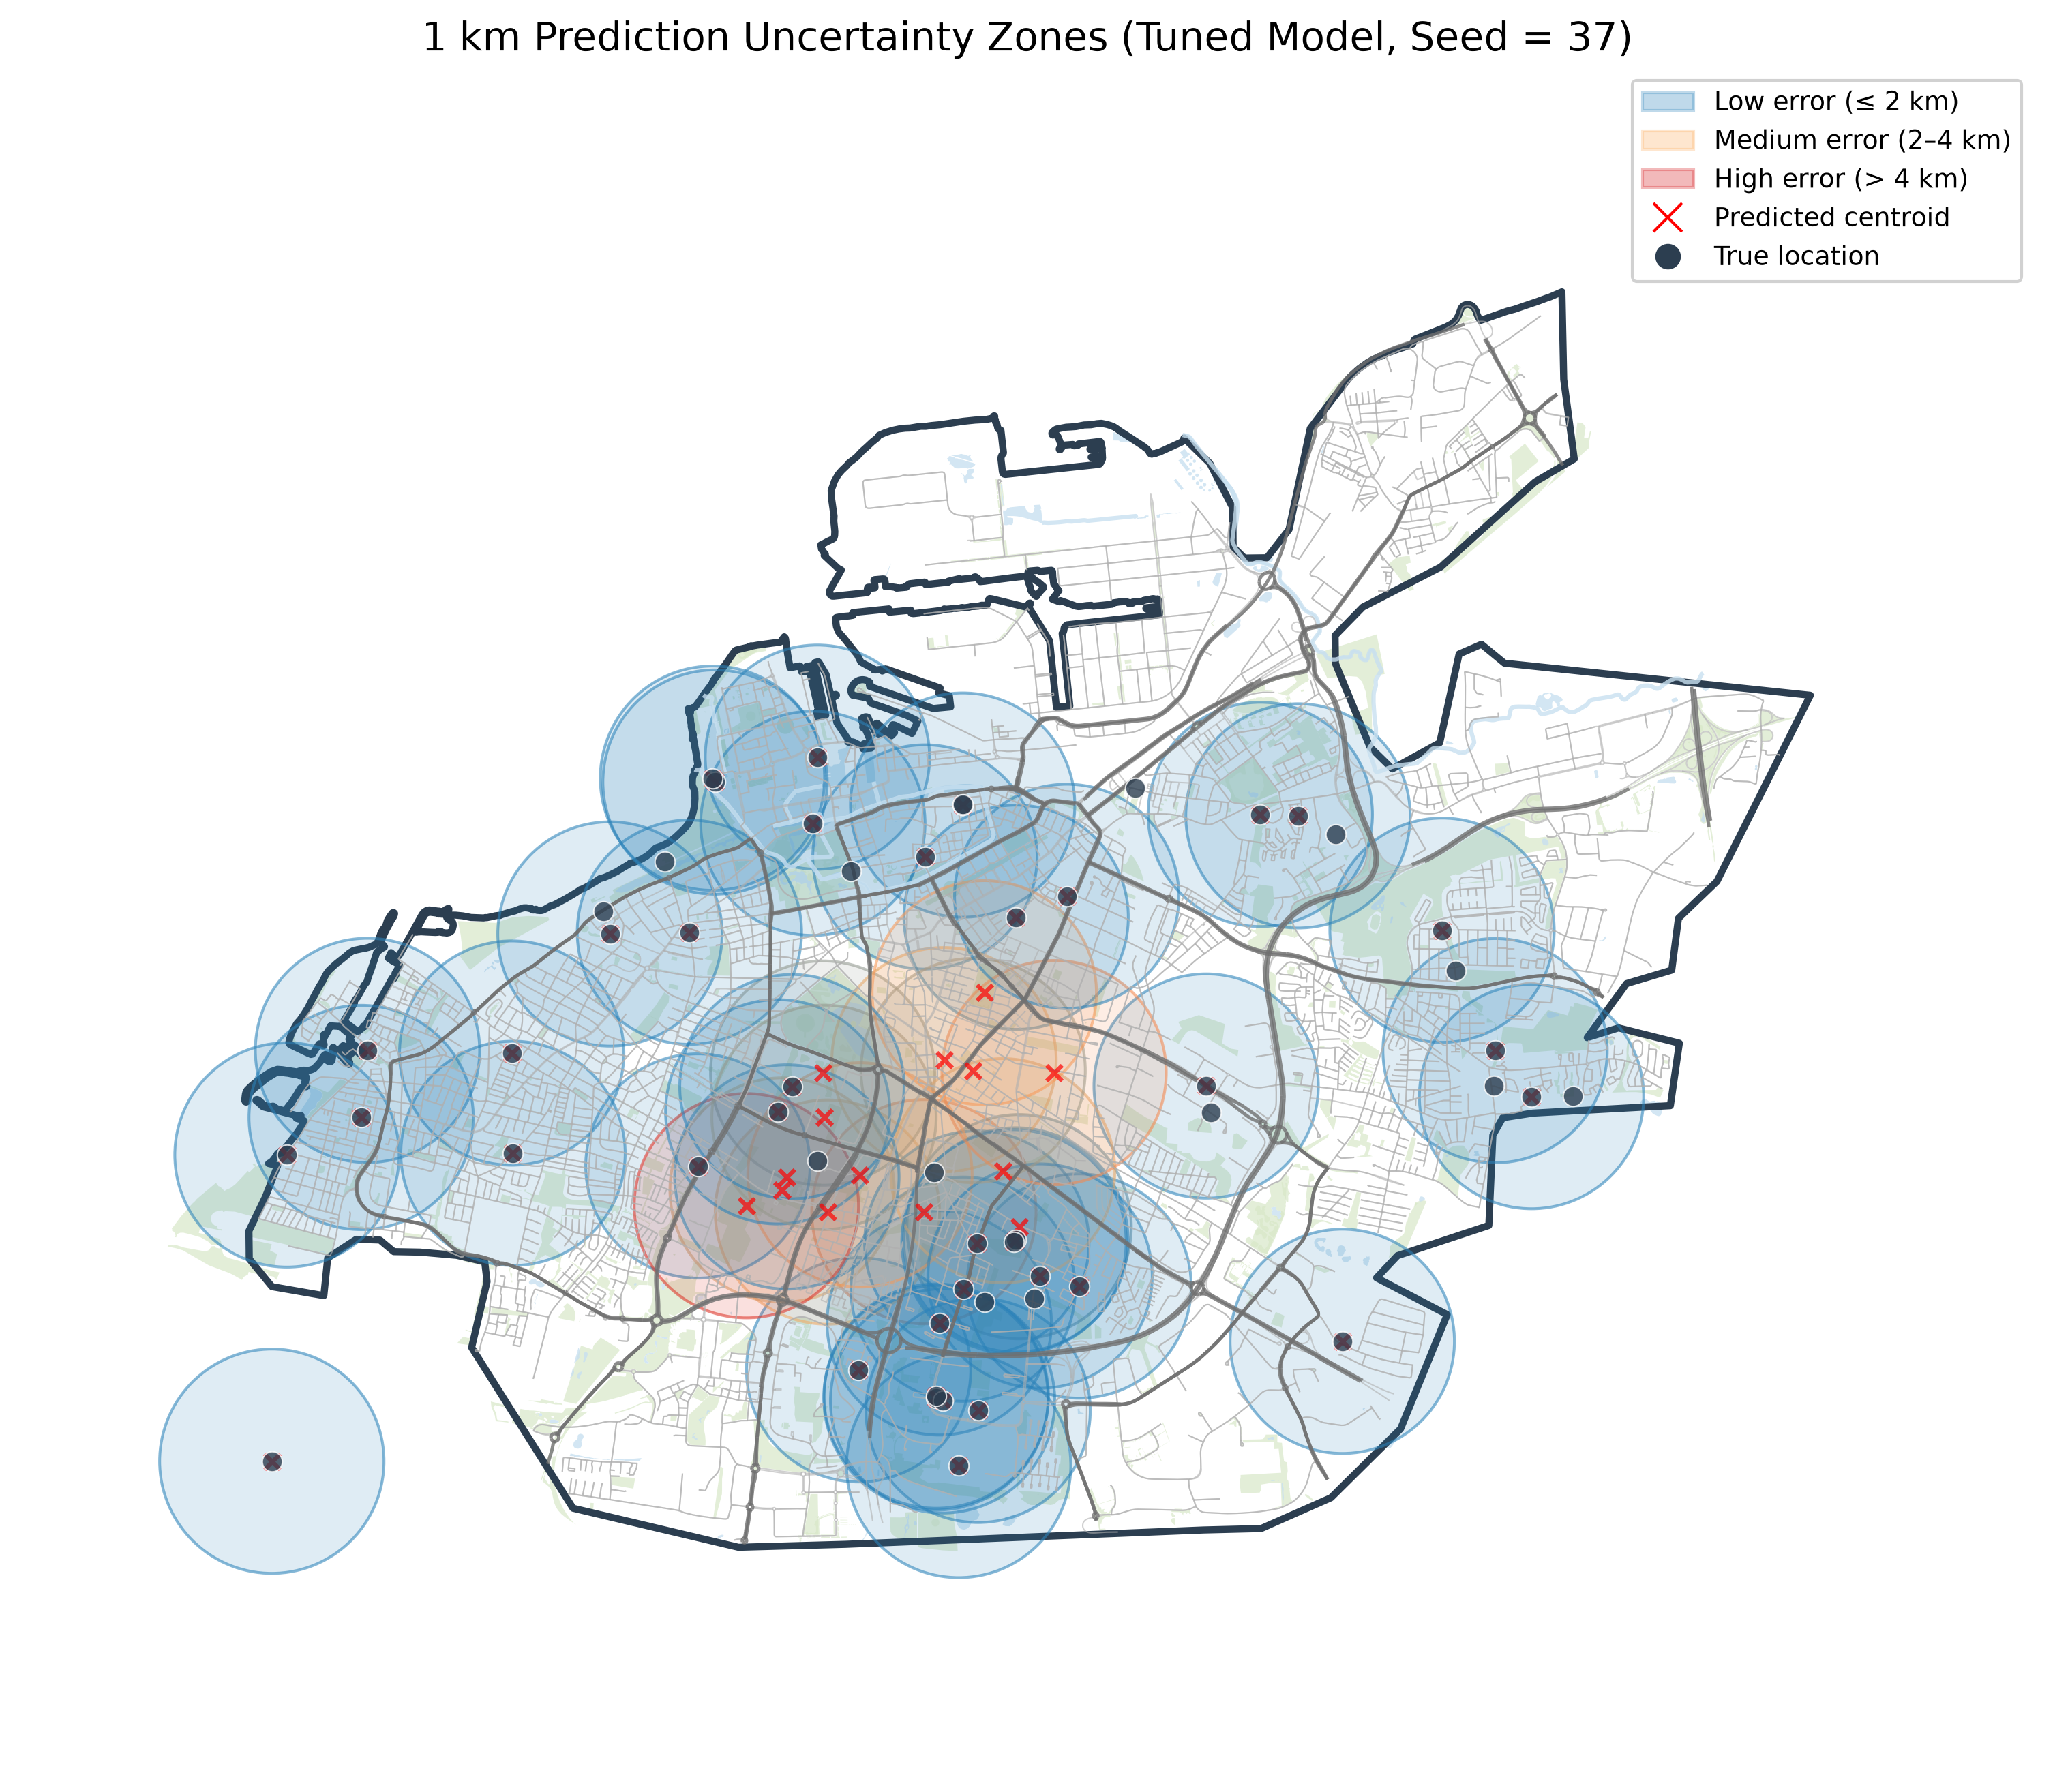

In [10]:
# -----------------------------------------------------------------------------
# 1. LOAD MAP & DATA (same as before)
# -----------------------------------------------------------------------------
print("Loading map and model...")
place_name = "Malmö, Sweden"
target_crs = "EPSG:3006"

boundary = ox.geocode_to_gdf(place_name).to_crs(target_crs)

def load_osm_features(place, tags):
    try:
        gdf = ox.features_from_place(place, tags=tags)
        return gdf.to_crs(target_crs) if not gdf.empty else gpd.GeoDataFrame()
    except:
        return gpd.GeoDataFrame()

water = load_osm_features(place_name, {"natural": "water", "waterway": ["river", "canal"]})
parks = load_osm_features(place_name, {"leisure": "park", "landuse": "grass", "natural": "wood"})

try:
    graph = ox.graph_from_place(place_name, network_type="drive")
    edges = ox.graph_to_gdfs(graph, nodes=False, edges=True).to_crs(target_crs)
    major = edges[edges["highway"].isin(["motorway", "trunk", "primary", "secondary"])]
    minor = edges[~edges["highway"].isin(["motorway", "trunk", "primary", "secondary"])]
except:
    major = gpd.GeoDataFrame()
    minor = gpd.GeoDataFrame()

# Load model
SEED = 37
original_rs = config.data_splitting.random_state
config.data_splitting.random_state = SEED
config.database.table = "malmo_order"
df = load_and_prep_data()
splitter = TrainTestSplit(df, n_splits=config.data_splitting.n_splits,
                          test_size=config.data_splitting.test_size)

X_test, y_test_zone, y_test_coords = splitter.get_test_data()
X_test = X_test.reindex(columns=splitter.X_cv.columns, fill_value=0.0)

pipeline = joblib.load("/home/chandru/binp51/src/ml/fe_model_group_kfold.joblib")
preds = pipeline.predict(X_test)

true_coords = y_test_coords[["X_meters", "Y_meters"]].values
config.data_splitting.random_state = original_rs

# -----------------------------------------------------------------------------
# 2. CALCULATE ERRORS
# -----------------------------------------------------------------------------
errors = np.sqrt(np.sum((preds - true_coords)**2, axis=1)) / 1000.0
RADIUS = 1000  # 1 km in meters

# -----------------------------------------------------------------------------
# 3. CREATE BUFFER CIRCLES WITH SLIGHT TRANSPARENCY
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_facecolor("#f5f5f0")

# Basemap layers
if not parks.empty: parks.plot(ax=ax, color="#d8e8c8", edgecolor="none", alpha=0.7)
if not water.empty: water.plot(ax=ax, color="#c8e0f0", edgecolor="none", alpha=0.8)
if not minor.empty: minor.plot(ax=ax, color="#b0b0b0", linewidth=0.5, alpha=0.6)
if not major.empty: major.plot(ax=ax, color="#707070", linewidth=1.2, alpha=0.8)
boundary.plot(ax=ax, facecolor="none", edgecolor="#2c3e50", linewidth=2.5)

# Plot each prediction as a transparent circle with error magnitude
# Use a colormap to show error intensity
from matplotlib.colors import LinearSegmentedColormap, Normalize
cmap = LinearSegmentedColormap.from_list("error_cmap", ["#2b83ba", "#fdae61", "#d7191c"], N=256)
norm = Normalize(vmin=0, vmax=errors.max() * 1.1)

for i, (x, y) in enumerate(preds):
    # Circle with transparency based on error
    alpha = 0.08 + 0.08 * (1 - errors[i] / errors.max())  # lower error = more transparent
    color = cmap(norm(errors[i]))
    circle = plt.Circle((x, y), RADIUS, color=color, alpha=0.15, linewidth=0.8, fill=True)
    ax.add_patch(circle)
    # Draw just the border
    circle_border = plt.Circle((x, y), RADIUS, color=color, alpha=0.5, linewidth=1.0, fill=False)
    ax.add_patch(circle_border)

# Plot predicted centroids (small dots)
ax.scatter(preds[:, 0], preds[:, 1], c='red', s=30, alpha=0.7, marker='x', linewidths=1.5, label='Predicted centroid', zorder=10)

# Plot true locations (larger dots)
ax.scatter(true_coords[:, 0], true_coords[:, 1], c='#2c3e50', s=50, alpha=0.8, marker='o', edgecolors='white', linewidth=0.5, label='True location', zorder=11)

# View limits
minx, miny, maxx, maxy = boundary.total_bounds
margin = 2000
ax.set_xlim(minx - margin, maxx + margin)
ax.set_ylim(miny - margin, maxy + margin)
ax.set_aspect("equal")
ax.axis("off")

# Legend
legend_elements = [
    Patch(facecolor="#2b83ba", alpha=0.3, edgecolor="#2b83ba", label="Low error (≤ 2 km)"),
    Patch(facecolor="#fdae61", alpha=0.3, edgecolor="#fdae61", label="Medium error (2–4 km)"),
    Patch(facecolor="#d7191c", alpha=0.3, edgecolor="#d7191c", label="High error (> 4 km)"),
    Line2D([0], [0], marker="x", color="red", linestyle="None", markersize=10, label="Predicted centroid"),
    Line2D([0], [0], marker="o", color="white", markerfacecolor="#2c3e50", markersize=10, label="True location")
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=9, framealpha=0.9)

ax.set_title(f"1 km Prediction Uncertainty Zones (Tuned Model, Seed = {SEED})", fontsize=14)

plt.tight_layout(pad=0.5)
#plt.savefig("/home/chandru/binp51/report/figures/prediction_confidence_circles.png", dpi=300, bbox_inches="tight")
plt.show()